
Training RNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6843 - loss: 0.5792 - val_accuracy: 0.8040 - val_loss: 0.4476
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8582 - loss: 0.3423 - val_accuracy: 0.8348 - val_loss: 0.3993
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9230 - loss: 0.2088 - val_accuracy: 0.8288 - val_loss: 0.4096
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9679 - loss: 0.1015 - val_accuracy: 0.8278 - val_loss: 0.4674
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9835 - loss: 0.0554 - val_accuracy: 0.8206 - val_loss: 0.5455

Training LSTM...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.7473 - loss: 0.4922 - val_accuracy: 0.8552 - val_loss: 0.3457
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.8927 - loss: 0.2689 - val_accuracy: 0.8678 - val_loss: 0.3101
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accurac

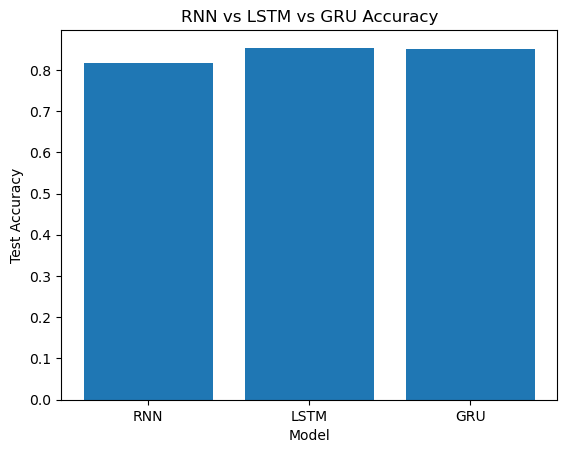

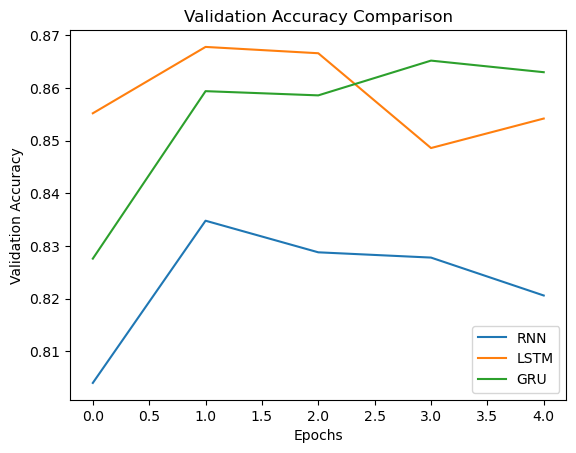

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding

# -----------------------------
# 1. Load Dataset
# -----------------------------
max_features = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# -----------------------------
# 2. Model Builder
# -----------------------------
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(max_features, 32, input_length=maxlen))
    
    if model_type == "RNN":
        model.add(SimpleRNN(32))
    elif model_type == "LSTM":
        model.add(LSTM(32))
    elif model_type == "GRU":
        model.add(GRU(32))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

# -----------------------------
# 3. Train + Store models
# -----------------------------
histories = {}
trained_models = {}

models = ["RNN", "LSTM", "GRU"]

for m in models:
    print(f"\nTraining {m}...")
    model = build_model(m)
    
    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )
    
    histories[m] = history
    trained_models[m] = model   # ✅ store trained model

# -----------------------------
# 4. Evaluate (NO retraining)
# -----------------------------
test_accuracies = {}

for m in models:
    loss, acc = trained_models[m].evaluate(x_test, y_test, verbose=0)
    test_accuracies[m] = acc

print("\nTest Accuracies:")
for k, v in test_accuracies.items():
    print(f"{k}: {v:.4f}")

# -----------------------------
# 5. Bar Graph (Accuracy)
# -----------------------------
plt.figure()
plt.bar(test_accuracies.keys(), test_accuracies.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy")
plt.show()

# -----------------------------
# 6. Line Graph (Validation Accuracy)
# -----------------------------
plt.figure()

for m in models:
    plt.plot(histories[m].history['val_accuracy'], label=m)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()